<img src="https://udemedellin.edu.co/wp-content/uploads/2022/10/logo_udemedellin2.png" width="30%">

**ESPECIALIZACIÓN EN CIENCIA DE DATOS E INTELIGENCIA ARTIFICIAL**

*INTRODUCCION A LA CIENCIA DE DATOS*<br>

DOCENTE:<br>
Mateo Cano Solis<br>

NOMBRES:
1. Santiago Castañeda Garcia
2. Andres Eduardo Medina
3. David Alejandro Montilla Orjuela



Abril 2026


---

# **Análisis Predictivo y Caracterización de la Contratación Estatal en Colombia: Un Enfoque Basado en Datos de SECOP I y II**

## **1. introducción:**
La contratación pública en Colombia representa uno de los pilares más importantes para el desarrollo socioeconómico del país. Con la transición y coexistencia de las plataformas SECOP I y SECOP II, se ha generado un volumen de información sin precedentes sobre cómo el Estado invierte sus recursos. Sin embargo, la complejidad y diversidad de estos datos exigen el uso de herramientas avanzadas de Analítica de Datos para transformar registros administrativos en conocimiento estratégico.

Este proyecto se enfoca en el estudio de los procesos de compra pública que han culminado en contratos efectivos. A través de técnicas de Aprendizaje Automático (Machine Learning), se busca descubrir patrones ocultos en las modalidades de selección, los tiempos de ejecución y la distribución de los presupuestos, permitiendo una visión técnica que aporte a la transparencia y a la eficiencia en la gestión pública

<br><br>

## **2. Objetivos:**

Objetivo General
Desarrollar un modelo de análisis basado en técnicas de aprendizaje automático para caracterizar y predecir métricas clave en los procesos de contratación estatal integrados en las plataformas SECOP I y II.

Objetivos Específicos
Realizar un Análisis Exploratorio de Datos (EDA) para identificar las tendencias de contratación por sectores, regiones y modalidades de selección.

Procesar y estandarizar la información integrada de SECOP I y II, gestionando la limpieza de datos faltantes y la codificación de variables categóricas.

Evaluar diferentes arquitecturas de modelos predictivos mediante el uso de herramientas de AutoML (como AutoGluon), con el fin de determinar el algoritmo que ofrezca mayor precisión en la clasificación o estimación de resultados contractuales.

Interpretar los resultados obtenidos para identificar qué variables (como cuantía, ubicación o tipo de entidad) tienen mayor peso en la configuración de un contrato exitoso.

<br>
VARIABLES OBSERVADAS
<br><br>

|Num|Nombre de la columna|Descripción|Nombre del campo API|Tipo de dato|
|-|-|-|-|-|
|1|Nivel Entidad|Nivel de la entidad publica que desarrolla el proceso de compra, de acuerdo a su cobertura|Nivel entidad|Texto|
|2|Código Entidad SECOP|Código de la entidad en la plataforma SEECOP|Código_entidad_en_secop|Texto |
|3|Nombre de la Entidad|Nombre de la Entidad que desarrolla el proceso de compra pública|nombre_de_la_entidad|Texto |
|4|NIT de la Entidad|	Identificador de la Entidad que desarrolla el proceso de compra pública|nit_de_la_entidad|	Texto|
|5|Departamento Entidad|	Departamento de origen de la Entidad en la plataforma SECOP|	departamento_entidad|	Texto|
|6|Municipio Entidad|	Municipio de origen de la Entidad en la plataforma SECOP|	municipio_entidad|	Texto|
|7|Estado del Proces|	Estado del proceso, de acuerdo con el flujo que se establece y a la modalidad de adquisición bajo la cual se desarrolla|	estado_del_proceso|	Texto|
|8|Modalidad de Contratación|	Modo de adquisición, de acuerdo con las características del proceso y del producto o servicio involucrados|	modalidad_de_contrataci_n|	Texto|
|9|Objeto del contrato|	Descripción detallada del producto o servicio a adquirir, definida al momento de redactar el contrato|	objeto_a_contratar|	Texto|
|10|Objeto del proceso|	Objeto de contratación registrado en la fase de publicación del proceso|	objeto_del_proceso|	Texto|
|11|Tipo de Contrato|	Tipo de contrato que se firma al finalizar el proceso de compra pública|	tipo_de_contrato|	Texto|
|12|Fecha de Firma del Contrato|	Fecha en que se firmó el contrato, sea de forma física o digital|	fecha_de_firma_del_contrato|	Marca de tiempo variable|
|13|Fecha inicio ejecución|	Fecha de Inicio de Ejecución del Contrato|	fecha_inicio_ejecuci_n|	Marca de tiempo variable|
|14|Fecha fin ejecución|	Fecha definida en el contrato como la fecha de finalización de la ejecución|	fecha_fin_ejecuci_n|	Marca de tiempo variable|
|15|ID Contrato|	Identificador en la plataforma del contrato firmado|	numero_del_contrato|	Texto|
|16|ID Proceso|	identificador en la plataforma del proceso desarrollado|	numero_de_proceso|	Texto|
|17|Valor Contrato|	Valor del contrato firmado|	valor_contrato	|numerica|
|18|Núm Raz Social Contratista|Nombre del contratista o de la empresa que proveerá los productos o servicios relacionados en el proceso de compra|num_raz_social_contratista|Texto|
|19|	URL Contrato|	URL del proceso en su correspondiente plataforma.|	url_contrato|	Texto|
|20	|Origen	|Plataforma Origen a donde pertenecen los datos|	origen	|Texto|
|21	|Tipo Documento Proveedor	|Corresponde al tipo de documento del proveedor	|tipo_documento_proveedor|	Texto|
|22|	Documento Proveedor	|Corresponde al número de documento del proveedor|	documento_proveedor	|Texto|






## **Carga de librerias y datos:**

In [1]:
#Importacion de librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import seaborn as sns
import unicodedata
import re
from catboost import CatBoostRegressor
import warnings
import seaborn as sns



df = pd.read_parquet('data/datos_secop.parquet')

#visualizar todo el df en pantalla
pd.set_option('display.max_columns', None)

# generar variable para conteo final de Nas
filas_iniciales = len(df)

#numero de columnas y filas
print(f"El dataset tiene: {df.shape[0]} filas y {df.shape[1]} columnas")



El dataset tiene: 300000 filas y 22 columnas


## **Variables**

In [3]:
df.columns.tolist()

['nivel_entidad',
 'codigo_entidad_en_secop',
 'nombre_de_la_entidad',
 'nit_de_la_entidad',
 'departamento_entidad',
 'municipio_entidad',
 'estado_del_proceso',
 'modalidad_de_contrataci_n',
 'objeto_a_contratar',
 'objeto_del_proceso',
 'tipo_de_contrato',
 'fecha_de_firma_del_contrato',
 'fecha_inicio_ejecuci_n',
 'fecha_fin_ejecuci_n',
 'numero_del_contrato',
 'numero_de_proceso',
 'valor_contrato',
 'nom_raz_social_contratista',
 'url_contrato',
 'origen',
 'tipo_documento_proveedor',
 'documento_proveedor']

## **Visualizar el df**

In [4]:
# Mostrar  5 filas aleatorias
df.sample(5,random_state=25)

,nivel_entidad,codigo_entidad_en_secop,nombre_de_la_entidad,nit_de_la_entidad,departamento_entidad,municipio_entidad,estado_del_proceso,modalidad_de_contrataci_n,objeto_a_contratar,objeto_del_proceso,tipo_de_contrato,fecha_de_firma_del_contrato,fecha_inicio_ejecuci_n,fecha_fin_ejecuci_n,numero_del_contrato,numero_de_proceso,valor_contrato,nom_raz_social_contratista,url_contrato,origen,tipo_documento_proveedor,documento_proveedor
98576,Territorial,706294725,MUNICIPIO DE PUERTO GAITAN,800079035,Meta,Puerto Gaitán,En ejecución,Contratación directa,PRESTACION DE SERVICIOS DE APOYO A LA GESTION ...,PRESTACION DE SERVICIOS DE APOYO A LA GESTION ...,Prestación de servicios,2025-10-24T00:00:00.000,2025-10-24T00:00:00.000,2025-12-24T00:00:00.000,CO1.PCCNTR.8496546,1457-2025,5693333,DANIELA STEFFANY ROJAS ORTIZ,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,1124818345
267521,Territorial,702730482,SUBRED INTEGRADA DE SERVICIOS DE SALUD SUR E.S...,900958564,Distrito Capital de Bogotá,Bogotá,Modificado,Contratación régimen especial,PRESTAR SERVICIOS COMO PROFESIONAL UNIVERSITAR...,PRESTAR SERVICIOS COMO PROFESIONAL UNIVERSITAR...,Prestación de servicios,2025-10-02T00:00:00.000,2025-10-02T00:00:00.000,2026-01-09T00:00:00.000,CO1.PCCNTR.8401984,7218-2025,12585600,Milena Stefany Lopez Ramirez,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,1018450196
286023,Territorial,701365033,MUNICIPIO DE ARMENIA QUINDIO,890000464,Quindío,Armenia,Aprobado,Contratación directa,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,Prestación de servicios,2025-11-27T00:00:00.000,None,2026-01-15T00:00:00.000,CO1.PCCNTR.8635700,SETTA-CD-2025-4677,3750000,Oscar Posada Yepes,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,7529900
11020,Territorial,702727421,empresa social del estado región de salud soacha.,8000068503,Cundinamarca,Soacha,Borrador,Contratación régimen especial,NO DEFINIDO,Sin Descripcion,Prestación de servicios,None,None,None,CO1.PCCNTR.272027,CO1.PCCNTR.272027,0,NO DEFINIDO,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Sin Descripcion,No Definido
219736,Territorial,702271321,(Secretaría Distrital de Integración Social),8999990619,Distrito Capital de Bogotá,No Definido,Aprobado,Contratación directa,PRESTAR SERVICIOS PROFESIONALES PARA REALIZAR ...,PRESTAR SERVICIOS PROFESIONALES PARA REALIZAR ...,Prestación de servicios,2025-11-18T00:00:00.000,None,2026-03-12T00:00:00.000,CO1.PCCNTR.8568972,11671-2025,15137640,DASSY MILENA GUTIERREZ,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,52288055


## **EDA**

In [5]:
# Obtener un resumen de la estructura del conjunto de datos:

print("\n-------TABLA CON TIPO DE VARIABLE VALORES UNICOS Y VALORES FALTANTES-------\n")
def generar_diccionario(Data):
    dicc = []
    for col in Data.columns:
        dicc.append({
            "Variable": col,
            "Tipo pandas": Data[col].dtype,
            "Cantidad de valores únicos": Data[col].nunique(),
            "Valores faltantes": Data[col].isna().sum()
        })
    return pd.DataFrame(dicc)

generar_diccionario(df)


-------TABLA CON TIPO DE VARIABLE VALORES UNICOS Y VALORES FALTANTES-------



,Variable,Tipo pandas,Cantidad de valores únicos,Valores faltantes
0,nivel_entidad,object,7,0
1,codigo_entidad_en_secop,object,5103,0
2,nombre_de_la_entidad,object,5239,0
3,nit_de_la_entidad,object,4200,0
4,departamento_entidad,object,38,0
5,municipio_entidad,object,1079,0
6,estado_del_proceso,object,19,0
7,modalidad_de_contrataci_n,object,31,0
8,objeto_a_contratar,object,165211,0
9,objeto_del_proceso,object,172952,1


In [5]:
'''# 1. Configuración de variables y grid
vars_cualitativas = [
    'nombre_de_la_entidad', 'departamento_entidad', 'municipio_entidad', 
    'estado_del_proceso', 'tipo_de_contrato', 'nom_raz_social_contratista'
]

cols_grid = 2
rows_grid = math.ceil(len(vars_cualitativas) / cols_grid)

# Paleta de colores
colores_paleta = plt.cm.tab10.colors 

fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(16, rows_grid * 5))
axes = axes.flatten()

for i, col in enumerate(vars_cualitativas):
    if col in df.columns:
        # Top 5 ordenado
        datos = df[col].value_counts().head(5).sort_values(ascending=True)

        ax = axes[i]
        
        # --- CAMBIO: Eliminamos 'label' para que no haya leyenda ---
        datos.plot(
            kind='barh', 
            ax=ax, 
            color=colores_paleta[:len(datos)], 
            edgecolor='black'
        )

        ax.set_title(f'Top 5: {col}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Cantidad de contratos')
        ax.set_ylabel('')

        # --- CAMBIO: Eliminamos ax.legend() ---
        # La leyenda ya no se mostrará.

        # Estética
        ax.grid(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Etiquetas de datos al final de la barra (aquí ya está el número)
        max_valor = datos.max()
        for p in ax.patches:
            ancho = p.get_width()
            ax.annotate(
                f' {int(ancho):,}', 
                (ancho, p.get_y() + p.get_height()/2.),
                va='center', 
                ha='left', 
                fontsize=11, 
                fontweight='bold'
            )
        
        ax.set_xlim(0, max_valor * 1.25)

    else:
        axes[i].axis('off')

# Ajustes finales
plt.tight_layout(pad=5.0)
fig.suptitle(
    'Top 5 de Variables Cualitativas - Análisis Visual',
    fontsize=22,
    fontweight='bold',
    y=1.02
)

plt.show()'''

"# 1. Configuración de variables y grid\nvars_cualitativas = [\n    'nombre_de_la_entidad', 'departamento_entidad', 'municipio_entidad', \n    'estado_del_proceso', 'tipo_de_contrato', 'nom_raz_social_contratista'\n]\n\ncols_grid = 2\nrows_grid = math.ceil(len(vars_cualitativas) / cols_grid)\n\n# Paleta de colores\ncolores_paleta = plt.cm.tab10.colors \n\nfig, axes = plt.subplots(rows_grid, cols_grid, figsize=(16, rows_grid * 5))\naxes = axes.flatten()\n\nfor i, col in enumerate(vars_cualitativas):\n    if col in df.columns:\n        # Top 5 ordenado\n        datos = df[col].value_counts().head(5).sort_values(ascending=True)\n\n        ax = axes[i]\n\n        # --- CAMBIO: Eliminamos 'label' para que no haya leyenda ---\n        datos.plot(\n            kind='barh', \n            ax=ax, \n            color=colores_paleta[:len(datos)], \n            edgecolor='black'\n        )\n\n        ax.set_title(f'Top 5: {col}', fontsize=13, fontweight='bold')\n        ax.set_xlabel('Cantidad de c

## **Renombrar columnas**

In [6]:
# Quitar guion para los nombres de las columnas
df.rename(columns={'modalidad_de_contrataci_n': 'modalidad_de_contratacion', 'fecha_inicio_ejecuci_n': 'fecha_inicio_ejecucion',
    'fecha_fin_ejecuci_n': 'fecha_fin_ejecucion'},
    inplace=True)

## **Data cleaning**

OBSERVACION: Existe en la columna (estado_del_proceso) contratos que estan en  borrador. lo que significa  que aun no están publicados oficialmente o no ha sido adjudicado o está en proceso de elaboración o revisión, por lo que carece de mucha de informacion en otras columnas, estas filas se eliminan para tener solo los contratos que ya pasaron la etapa de creación inicial

In [7]:
#Borrar contratos en estado borrador
df["estado_del_proceso"] = df["estado_del_proceso"].astype(str)
df["estado_del_proceso"] = df["estado_del_proceso"].str.lower()
df = df[df['estado_del_proceso'] != 'borrador']

#comprobamos cuantas filas quedan
print(f"el numero de filas resultantes es {df.shape[0]}")



el numero de filas resultantes es 272015


OBSERVACION: El dataset nos quedo con 272015 filas lo cual nos dice que exisitian  27958 contratos que a la fecha no se han aprobado y fueron eliminados para nuestro estudio, ademas tenemos  75269  filas que no tienen fecha de inicio de ejecucion (fecha_inicio_ejecucion), esto puede deberse que el contrato aun no se ha iniciado por lo que no debe tener fecha de terminacion (fecha_fin_ejecucion). Buscamos las filas que no tienen fechas en ninguna de las dos columnas (fantasmas).

Pasar variables de fecha a formato datetime


In [8]:
#numero de filas sin fecha de inicio de ejcucion
filas_sin_fecha_ejecucion=df['fecha_inicio_ejecucion'].isna().sum()
print(f"el numero de filas sin fecha de inicio de ejcucion es: {filas_sin_fecha_ejecucion}")

el numero de filas sin fecha de inicio de ejcucion es: 75269


In [9]:
#aplicar fomato datetime

cols = ['fecha_de_firma_del_contrato', 'fecha_inicio_ejecucion', 'fecha_fin_ejecucion']

df[cols] = df[cols].apply(
    lambda x: pd.to_datetime(x, errors='coerce').dt.normalize()
)

In [10]:
# 1. Obtenemos los índices de las filas con fecha de inicio nula
indices_sin_inicio = set(df[df['fecha_inicio_ejecucion'].isna()].index)

# 2. Obtenemos los índices de las filas con fecha de fin nula
indices_sin_fin = set(df[df['fecha_fin_ejecucion'].isna()].index)

# 3. Usamos la intersección (&) para saber cuáles no tienen NINGUNA de las dos
filas_sin_ambas = indices_sin_inicio & indices_sin_fin

print(f"Cantidad de contratos sin ambas fechas: {len(filas_sin_ambas)}")

df_fantasmas = df.loc[list(filas_sin_ambas)]


Cantidad de contratos sin ambas fechas: 26839


Existen 26839 contratos sin fechas de inicio y de ejecucion, y comprobamos los estados del proceso para las filas que no tienen fechas de inicio de ejecucion ni fin de ejecucion.

In [11]:
df_fantasmas["estado_del_proceso"].unique()

array(['convocado', 'adjudicado',
       'terminado anormalmente después de convocado', 'descartado',
       'cancelado', 'publicación para manifestaciones de interés',
       'enviado proveedor', 'aprobado'], dtype=object)

OBERVACION:

estos estados corroboran la siguiente informacion


El grupo de "No llegaron a nacer" (Convocado, Adjudicado, Aprobado)
Convocado / Publicación para manifestaciones: El proceso apenas está en licitación. La entidad está buscando quién lo haga. No hay fechas de ejecución porque no hay contrato todavía.

Adjudicado: Ya hay un ganador, pero están en el trámite de firmas. El reloj de la ejecución no ha empezado a correr.

Aprobado / Enviado Proveedor: Son estados de la plataforma SECOP II donde el documento está en "bandeja de entrada", pero no se ha formalizado el acta de inicio.

El grupo de "Muerte Súbita" (Cancelado, Descartado, Terminado Anormalmente)
Cancelado / Descartado: La entidad decidió no seguir adelante antes de que empezara el trabajo. Es lógico que no tengan fechas de inicio ni fin, porque el contrato murió en el papel.

Terminado Anormalmente después de Convocado: Este es muy interesante para las anomalías. Significa que el proceso se rompió justo después de abrirse. Puede ser por falta de oferentes, errores en los pliegos o incluso denuncias de corrupción que frenaron el proceso.


Para nuestro estudio eliminaremos estas filas ya que necesitaremos fechas para poder correr nuestro modelo

In [12]:
#Elimina filas sin ambas fechas

df = df.drop(index=list(filas_sin_ambas)).copy()

borramos contratos con valores cero e inferiores a 1 millon

In [13]:
# Conteo de ceros y negativos
inferiores_1_millon= (df['valor_contrato'] < 1000000).sum()
print(f"Valores menores a 1 millon: {inferiores_1_millon}")

Valores menores a 1 millon: 5010


eliminamos esas filas con contratos menores a 1 millon de pesos

In [14]:
# Obtenemos los índices de las filas que queremos borrar

df = df[df['valor_contrato'] >= 1000000]

## **Imputacion**

aun tenemos 48430 filas sin (fecha_inicio_ejecucion) por lo que hacemos imputacion de estos valores con la (fecha_de_firma_del_contrato) ya que muchos contratos inician el mismo día que se firman. 

In [17]:
print("-----Valores faltantes------")
df[cols].isna().sum()

-----Valores faltantes------


fecha_de_firma_del_contrato    4655
fecha_inicio_ejecucion         1695
fecha_fin_ejecucion               7
dtype: int64

In [18]:
# Imputar fehca de firma de contrato a fecha inicio de ejecucion
df['fecha_inicio_ejecucion'] = df['fecha_inicio_ejecucion'].fillna(df['fecha_de_firma_del_contrato'])

In [19]:
print("-----Valores faltantes------")
df[cols].isna().sum()

-----Valores faltantes------


fecha_de_firma_del_contrato    4655
fecha_inicio_ejecucion         1695
fecha_fin_ejecucion               7
dtype: int64

Borramos los que aún no tienen fecha de inicio (porque no tenían fecha de firma para rescatarlos)

In [20]:
df = df.dropna(subset=[
    'fecha_inicio_ejecucion',
    'fecha_fin_ejecucion'
])

## **Nueva variable duracion del contrato**

Creamos una variable que nos diga cuanto duro el contrato en dias

In [21]:
#Calculamos la duración en días
df['duracion_dias'] = (df['fecha_fin_ejecucion'] - df['fecha_inicio_ejecucion']).dt.days

#Revisamos si hay anomalías obvias de inmediato
print("Estadísticas de la duración:")
print(df['duracion_dias'].describe())

#(Duración negativa)
negativos = (df['duracion_dias'] < 0).sum()
print(f"\n Contratos con fechas invertidas: {negativos}")


Estadísticas de la duración:
count    238464.000000
mean        154.544673
std         190.743590
min       -7256.000000
25%          49.000000
50%         105.000000
75%         249.000000
max        8065.000000
Name: duracion_dias, dtype: float64

 Contratos con fechas invertidas: 871


existen 886 contratos con duraciones negativas esto puede deberse a errores de digitacion, para nuestro ejercicio eliminamos esas filas, estos serian contratos a revisar, pero para nuestro estudio estos contratos no aportarian informacion, por lo que los eliminamos del dataset.

In [22]:
# 1. Filtramos para trabajar solo con duraciones lógicas (mayores a 0)
df = df[df['duracion_dias'] > 0].copy()

In [23]:
filas_finales=len(df)

porcentaje_filas_eliminadas = (filas_iniciales - filas_finales)*100/filas_iniciales

print(f"\n filas con fechas completas: {filas_finales}")
print(f"\n filas iniciales dataset: {filas_iniciales}")
print(f"\n porcentaje eliminados: {round(porcentaje_filas_eliminadas,2)} %")


 filas con fechas completas: 237130

 filas iniciales dataset: 300000

 porcentaje eliminados: 20.96 %


Creamos una nueva variable llamada anio para extraer el año de la fecha de ejecucion del contrato


In [24]:
df['anio'] = df['fecha_inicio_ejecucion'].dt.year.astype('Int64')
df['mes'] = df['fecha_inicio_ejecucion'].dt.month.astype('Int64')


In [25]:
df.head(5)

,nivel_entidad,codigo_entidad_en_secop,nombre_de_la_entidad,nit_de_la_entidad,departamento_entidad,municipio_entidad,estado_del_proceso,modalidad_de_contratacion,objeto_a_contratar,objeto_del_proceso,tipo_de_contrato,fecha_de_firma_del_contrato,fecha_inicio_ejecucion,fecha_fin_ejecucion,numero_del_contrato,numero_de_proceso,valor_contrato,nom_raz_social_contratista,url_contrato,origen,tipo_documento_proveedor,documento_proveedor,duracion_dias,anio,mes
0,TERRITORIAL,50000005,QUINDÍO - INDEPORTES QUINDÍO,801001532,Quindío,Circasia,terminado sin liquidar,Contratación Directa (Ley 1150 de 2007),PRESTAR LOS SERVICIOS DE APOYO A LA GESTION EN...,PRESTAR LOS SERVICIOS DE APOYO A LA GESTIoN EN...,Prestación de Servicios,2015-11-17,2015-11-17,2015-12-17,15-12-4416408,224-2015 Contrato de prestación de servicio,1500000,ANDERSON ANTONIO URBANO RUALES,https://www.contratos.gov.co/consultas/detalle...,SECOPI,Cédula de Ciudadanía,18130744,30,2015,11
1,TERRITORIAL,50000005,QUINDÍO - INDEPORTES QUINDÍO,801001532,Quindío,Circasia,terminado sin liquidar,Contratación Directa (Ley 1150 de 2007),PRESTAR LOS SERVICIOS DE APOYO A LA GESTION EN...,PRESTAR LOS SERVICIOS DE APOYO A LA GESTIoN EN...,Prestación de Servicios,2015-11-17,2015-11-17,2015-12-17,15-12-4418304,227-2015 Contrato de Prestacion de servicio,1500000,JUAN SEBASTIAN BUITRAGO,https://www.contratos.gov.co/consultas/detalle...,SECOPI,Cédula de Ciudadanía,1094885358,30,2015,11
2,TERRITORIAL,50000005,QUINDÍO - INDEPORTES QUINDÍO,801001532,Quindío,Circasia,terminado sin liquidar,Contratación Directa (Ley 1150 de 2007),PRESTAR LOS SERVICIOS DE APOYO A LA GESTION EN...,PRESTAR LOS SERVICIOS DE APOYO A LA GESTIoN EN...,Prestación de Servicios,2015-11-17,2015-11-17,2015-12-17,15-12-4418312,230-2015 Contrato de Prestacion de servicio,1400000,JULIAN MAURICIO OCAMPO,https://www.contratos.gov.co/consultas/detalle...,SECOPI,Cédula de Ciudadanía,4375686,30,2015,11
3,TERRITORIAL,50000005,QUINDÍO - INDEPORTES QUINDÍO,801001532,Quindío,Circasia,terminado sin liquidar,Contratación Directa (Ley 1150 de 2007),PRESTAR LOS SERVICIOS DE APOYO A LA GESTION EN...,PRESTAR LOS SERVICIOS DE APOYO A LA GESTIoN EN...,Prestación de Servicios,2015-11-17,2015-11-17,2015-12-17,15-12-4418338,234-2015 Contrato de Prestacion de servicio,1500000,JUAN PABLO CASTANEDA DAZA,https://www.contratos.gov.co/consultas/detalle...,SECOPI,Cédula de Ciudadanía,1.097.390.531,30,2015,11
4,TERRITORIAL,50000005,QUINDÍO - INDEPORTES QUINDÍO,801001532,Quindío,Circasia,terminado sin liquidar,Contratación Directa (Ley 1150 de 2007),PRESTAR LOS SERVICIOS DE APOYO A LA GESTION EN...,PRESTAR LOS SERVICIOS DE APOYO A LA GESTIoN EN...,Prestación de Servicios,2016-04-04,2016-04-04,2016-08-04,16-12-4954064,contrato de prestación de servicios 045 de 2016,4200000,ERICK ALBERTO GAMRO VEGA,https://www.contratos.gov.co/consultas/detalle...,SECOPI,Cédula de Ciudadanía,7603987,122,2016,4


ponemos como indice del df el numero del contrato

Eliminamos columnas innecesarias para modelar

In [26]:
#eliminar columnas que no usaremos en el modelado
columns_eliminar = ["nit_de_la_entidad",  
                    "numero_de_proceso",
                    "numero_del_contrato",
                    "objeto_a_contratar",
                    "nom_raz_social_contratista",
                    "documento_proveedor", 
                    "url_contrato",
                    "numero_del_contrato",
                    "fecha_de_firma_del_contrato",
                    "tipo_documento_proveedor",
                    "codigo_entidad_en_secop",
                    "fecha_inicio_ejecucion",
                    "fecha_fin_ejecucion"
                    ]

df= df.drop(columns=columns_eliminar)


analizamos la variable año (anio) para poder traer valor de los contratos a precio actual usando el ipc de cada año, (fuente DANE)

In [27]:
lista_anios = sorted(df['anio'].unique().tolist())
print(lista_anios)

[2007, 2008, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027]


In [28]:
#eliminemos contratos con fecha de 2027
df = df[df['anio'] != 2027]

fuente de ipc pagina DANE

In [29]:
ipc_df = pd.DataFrame({
    'anio': [2007, 2008, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026],
    'ipc': [5.69, 7.67, 3.73, 2.44, 1.94, 3.66, 6.77, 5.75, 4.09, 3.18, 3.80, 1.61, 5.62, 13.12, 9.28, 5.20, 5.10, 5.56]
})

df = df.merge(ipc_df, on='anio', how='left')

In [30]:
#creamos columna con valor actual 

ipc_base = 5.66  #IPC a marzo de 2026

df['valor_ajustado'] = df['valor_contrato'] * (ipc_base / df['ipc'])

In [31]:
generar_diccionario(df)

,Variable,Tipo pandas,Cantidad de valores únicos,Valores faltantes
0,nivel_entidad,object,6,0
1,nombre_de_la_entidad,object,4227,0
2,departamento_entidad,object,37,0
3,municipio_entidad,object,1033,0
4,estado_del_proceso,object,14,0
5,modalidad_de_contratacion,object,23,0
6,objeto_del_proceso,object,153504,0
7,tipo_de_contrato,object,30,0
8,valor_contrato,int64,88695,0
9,origen,object,2,0


## **Análisis de la variable valor ajustado**

<Axes: xlabel='valor_ajustado', ylabel='Count'>

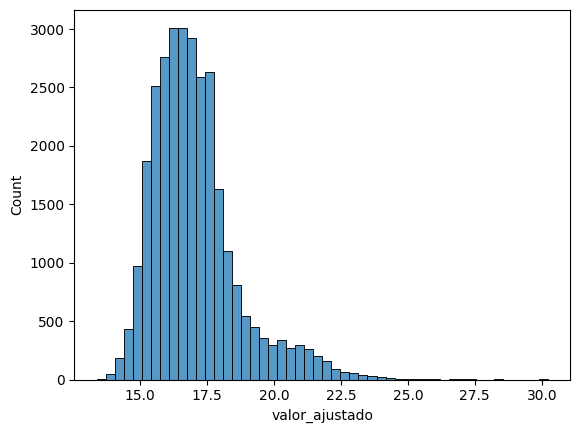

In [32]:
import numpy as np

sample = np.log1p(df["valor_ajustado"].sample(30000, random_state=42))

sns.histplot(sample, bins=50, kde=False)


Análisis de la distribución de la variable valor_ajustado (valor contrato con IPC)

El histograma de la variable valor_ajustado (en escala logarítmica) presenta una distribución aproximadamente normal, con ligera asimetría positiva. La mayor concentración de observaciones se encuentra en un rango intermedio, lo que indica una predominancia de contratos de cuantía media dentro del conjunto de datos.

La transformación logarítmica aplicada resulta adecuada, ya que reduce la dispersión y mejora la simetría de la distribución, facilitando el proceso de modelado y contribuyendo a una mayor estabilidad en los algoritmos de regresión.

No obstante, se identificó la presencia de una cola larga hacia la derecha, asociada a valores atípicos correspondientes a contratos de muy alta cuantía. Con el fin de mitigar el impacto de estos valores extremos sobre el desempeño del modelo, se optó por aplicar un recorte en el percentil 90 (P90), eliminando así las observaciones más extremas.

Esta decisión permite reducir la influencia de outliers, mejorar la capacidad de generalización del modelo y obtener métricas de evaluación más representativas del comportamiento general de los datos, sin perder información significativa de la mayoría de las observaciones.

In [33]:
limite = df["valor_ajustado"].quantile(0.90)
df_filtrado = df[df["valor_ajustado"] <= limite]

In [34]:
df_filtrado = df_filtrado.drop(columns=['ipc','valor_contrato'])

In [35]:
generar_diccionario(df_filtrado)

,Variable,Tipo pandas,Cantidad de valores únicos,Valores faltantes
0,nivel_entidad,object,6,0
1,nombre_de_la_entidad,object,4023,0
2,departamento_entidad,object,37,0
3,municipio_entidad,object,1025,0
4,estado_del_proceso,object,14,0
5,modalidad_de_contratacion,object,21,0
6,objeto_del_proceso,object,136729,0
7,tipo_de_contrato,object,30,0
8,origen,object,2,0
9,duracion_dias,int64,864,0


In [36]:
df_filtrado.shape[0]

213416

Limpieza de las filas eliminando tildes, espacios, urls, numeros con la funcion limpieza_total ya creada

In [37]:
from limpieza_texto import limpieza_total

# Definimos las columnas a ignorar
ignore = ['valor_ajustado','anio','duracion_dias','origen','fecha_inicio_ejecucion','fecha_fin_ejecucion','mes']
target_cols = [c for c in df_filtrado.columns if c not in ignore]

# Aplicamos la función 
df_filtrado[target_cols] = df_filtrado[target_cols].map(limpieza_total)


Filas eliminadas en total 

In [38]:
filas_finales=len(df_filtrado)

porcentaje_filas_eliminadas = (filas_iniciales - filas_finales)*100/filas_iniciales

print(f"\n filas con fechas completas: {filas_finales}")
print(f"\n filas iniciales dataset: {filas_iniciales}")
print(f"\n porcentaje eliminados: {round(porcentaje_filas_eliminadas,2)} %")


 filas con fechas completas: 213416

 filas iniciales dataset: 300000

 porcentaje eliminados: 28.86 %


Tomamos una muestra para el modelo

In [39]:
# Tomar una muestra del 30% (aprox. 80,000 filas)
df_sample = df_filtrado.sample(frac=0.3, random_state=42).reset_index(drop=True)

#guardamos el archivo para poder trabajar con embeddings
df_sample.to_csv('data/dataset_limpio_contratos.csv', index=False)

In [40]:
df_sample.head()

,nivel_entidad,nombre_de_la_entidad,departamento_entidad,municipio_entidad,estado_del_proceso,modalidad_de_contratacion,objeto_del_proceso,tipo_de_contrato,origen,duracion_dias,anio,mes,valor_ajustado
0,territorial,orquesta filarmonica de bogota,distrito capital de bogota,bogota,en ejecucion,contratacion directa,prestar los servicios profesionales como artis...,prestacion de servicios,SECOPII,137,2025,8,2.015942e+07
1,territorial,gobernacion del cauca,cauca,popayan,modificado,contratacion directa,prestar servicios profesionales para apoyar en...,prestacion de servicios,SECOPII,143,2025,8,1.996167e+07
2,territorial,instituto de deportes y recreacion de medellin,antioquia,medellin,cerrado,contratacion directa,prestar los servicios profesionales y de apoyo...,prestacion de servicios,SECOPII,181,2024,7,4.067757e+07
3,nacional,fondo de pasivo social de ferrocarriles nacion...,cundinamarca,no definido,modificado,contratacion directa,prestar los servicios profesionales en asuntos...,prestacion de servicios,SECOPII,306,2025,2,9.191924e+07
4,territorial,empresa social del estado region de salud soacha.,cundinamarca,soacha,modificado,contratacion regimen especial,prestacion de servicios como profesional en me...,prestacion de servicios,SECOPII,32,2024,12,8.045908e+06


In [42]:
generar_diccionario(df_sample)

,Variable,Tipo pandas,Cantidad de valores únicos,Valores faltantes
0,nivel_entidad,object,4,0
1,nombre_de_la_entidad,object,3122,0
2,departamento_entidad,object,35,0
3,municipio_entidad,object,935,0
4,estado_del_proceso,object,14,0
5,modalidad_de_contratacion,object,13,0
6,objeto_del_proceso,object,43850,0
7,tipo_de_contrato,object,23,0
8,origen,object,2,0
9,duracion_dias,int64,640,0


MODELO CATBOOST

In [156]:
# Definimos las columnas categóricas por nombre 
cat_features = [
    'nivel_entidad', 
    'departamento_entidad',
    'nombre_de_la_entidad',
    'municipio_entidad', 
    'estado_del_proceso', 
    'modalidad_de_contratacion', 
    'tipo_de_contrato', 
    'origen',
    'anio',
    'mes'
]
text_features = ['objeto_del_proceso']

In [159]:
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# 1. Preparar X e y con transformación logarítmica
X = df_sample.drop('valor_ajustado', axis=1)
# Usamos log1p para evitar errores con ceros: log(1 + x)
y_log = np.log1p(df_sample['valor_ajustado'])

# 2. División de datos (ahora con el target transformado)
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# 3. Crear los Pools
# Asegúrate de que cat_features y text_features estén definidos antes
train_pool = Pool(
    X_train, 
    y_train_log, 
    cat_features=cat_features, 
    text_features=text_features
)

test_pool = Pool(
    X_test, 
    y_test_log, 
    cat_features=cat_features, 
    text_features=text_features
)

# 4. Configurar el modelo con mejores parámetros para texto y profundidad
model = CatBoostRegressor(
    iterations=4000,
    learning_rate=0.05,        
    depth=8,                  
    loss_function='RMSE',
    random_seed=42,
    verbose=200,
    early_stopping_rounds=200 # Se detiene si deja de mejorar en el test
)

# 5. Entrenar
model.fit(train_pool, eval_set=test_pool, plot=True)

# --- EVALUACIÓN (Volviendo a la escala original) ---

# 6. Predecir en escala logarítmica
preds_log = model.predict(X_test)

# 7. Invertir la transformación: exp(x) - 1
preds_final = np.expm1(preds_log)
y_test_original = np.expm1(y_test_log)

# 8. Calcular el error real en pesos
mae_final = mean_absolute_error(y_test_original, preds_final)
print(f"--------------------------------------------------")
print(f"Error Medio Absoluto (MAE): ${mae_final:,.2f} pesos")
print(f"--------------------------------------------------")

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 1.0182222	test: 1.0141682	best: 1.0141682 (0)	total: 292ms	remaining: 19m 28s
200:	learn: 0.5083089	test: 0.5059055	best: 0.5059055 (200)	total: 48.7s	remaining: 15m 20s
400:	learn: 0.4712312	test: 0.4852238	best: 0.4852238 (400)	total: 1m 34s	remaining: 14m 11s
600:	learn: 0.4483608	test: 0.4754086	best: 0.4754086 (600)	total: 2m 20s	remaining: 13m 13s
800:	learn: 0.4302696	test: 0.4693153	best: 0.4693153 (800)	total: 3m 6s	remaining: 12m 24s
1000:	learn: 0.4152420	test: 0.4646936	best: 0.4646936 (1000)	total: 3m 53s	remaining: 11m 39s
1200:	learn: 0.4020342	test: 0.4609185	best: 0.4609185 (1200)	total: 4m 40s	remaining: 10m 53s
1400:	learn: 0.3905174	test: 0.4580571	best: 0.4580571 (1400)	total: 5m 28s	remaining: 10m 8s
1600:	learn: 0.3800932	test: 0.4558360	best: 0.4558360 (1600)	total: 6m 15s	remaining: 9m 23s
1800:	learn: 0.3704114	test: 0.4534793	best: 0.4534793 (1800)	total: 7m 5s	remaining: 8m 39s
2000:	learn: 0.3615162	test: 0.4516086	best: 0.4516086 (2000)	total: 7m

In [160]:
from evaluar_model import evaluar_modelo

# 1. El modelo hace las predicciones (todavía están en escala logarítmica)
print("Realizando predicciones...")
preds_log = model.predict(X_test)

# 2. Llamas a la función que creamos antes
# Asegúrate de haber ejecutado la celda donde definiste def evaluar_modelo()
resultados = evaluar_modelo(y_test_log, preds_log)

Realizando predicciones...
--- Evaluación del Modelo (Escala Real) ---
R² (Varianza explicada): 0.6588
MAE (Error promedio):    $8,251,245.79
RMSE (Penaliza errores): $18,980,926.38
MAPE (Error porcentual): 31.04%
-------------------------------------------


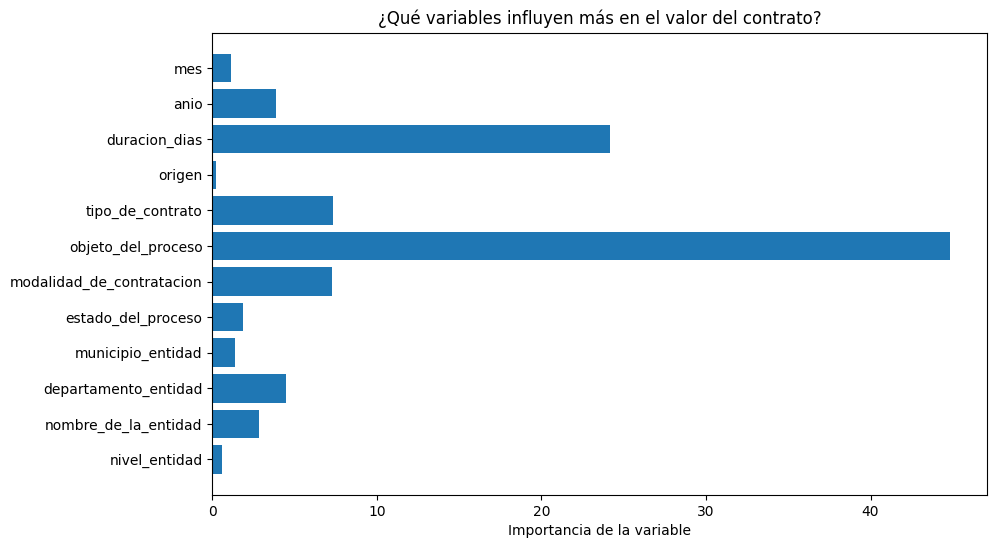

In [161]:
import matplotlib.pyplot as plt

# Obtener importancia
feature_importance = model.get_feature_importance(train_pool)
feature_names = X_train.columns

# Graficar
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importance)
plt.xlabel('Importancia de la variable')
plt.title('¿Qué variables influyen más en el valor del contrato?')
plt.show()

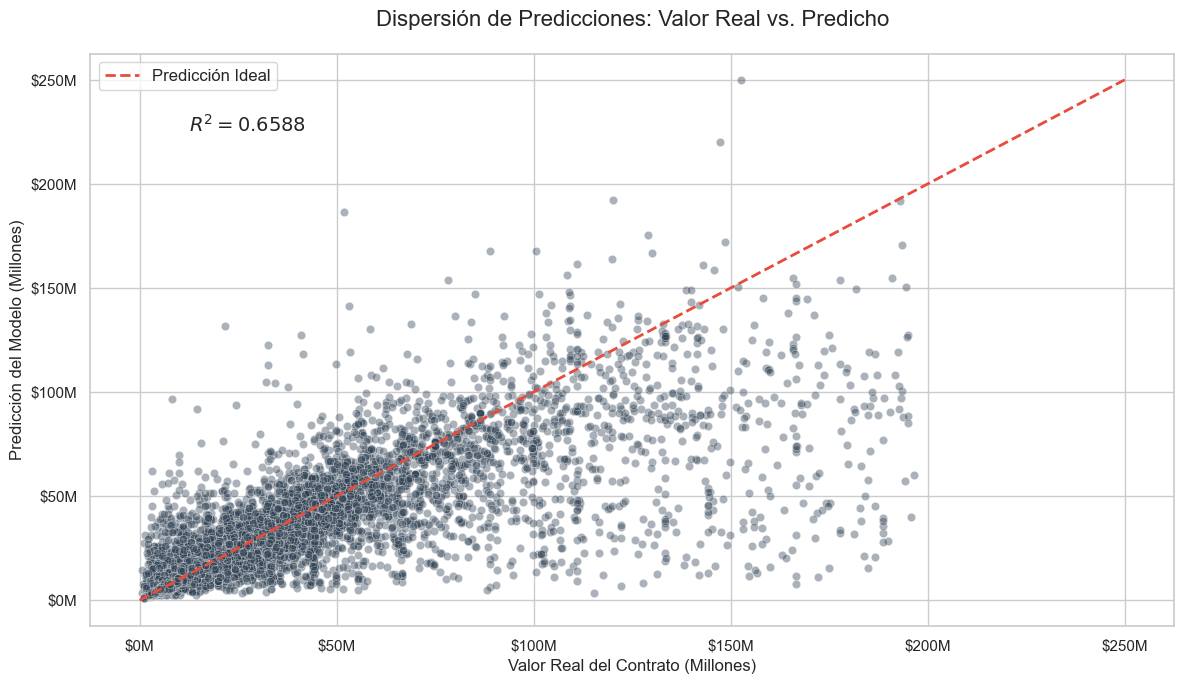

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# 2. Crear el scatter plot
# Usamos tus variables: y_test_original y preds_final
sns.scatterplot(x=y_test_original, y=preds_final, alpha=0.4, color='#2c3e50', edgecolor="w")

# 3. Línea de referencia (Identidad: donde Real == Predicho)
# Buscamos el valor máximo entre ambos para que la línea cubra todo el gráfico
limite_max = max(y_test_original.max(), preds_final.max())
plt.plot([0, limite_max], [0, limite_max], color='#e74c3c', linestyle='--', linewidth=2, label='Predicción Ideal')

# 4. Formatear ejes (Para que no salgan números gigantes como 1e7)
def format_millones(x, pos):
    return f'${x/1e6:.0f}M'

from matplotlib.ticker import FuncFormatter
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_millones))
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_millones))

# 5. Etiquetas y Títulos
plt.title('Dispersión de Predicciones: Valor Real vs. Predicho', fontsize=16, pad=20)
plt.xlabel('Valor Real del Contrato (Millones)', fontsize=12)
plt.ylabel('Predicción del Modelo (Millones)', fontsize=12)
plt.legend(fontsize=12)

# 6. Mostrar métricas clave dentro del gráfico para referencia rápida
r2_val = 0.6588 # El que obtuviste antes
plt.text(limite_max*0.05, limite_max*0.9, f'$R^2 = {r2_val:.4f}$', 
         fontsize=14, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

**Resumen de la Arquitectura** <br>
Modelo: CatBoost Regressor.

Procesamiento de Texto: Se utilizó un modelo de lenguaje (BERT) para generar embeddings del objeto_del_proceso, reducidos a 30 componentes principales mediante PCA.
Variables Temporales: Inclusión de fecha_inicio_ejecucion y fecha_fin_ejecucion mediante la extracción de características (Mes, Año, Trimestre) para capturar estacionalidad e inflación.
Tratamiento del Target: Aplicación de transformación logarítmica (log1p) sobre el valor del contrato para estabilizar la varianza y normalizar la distribución de precios.

**Métricas de Desempeño** <br>
Tras 4,000 iteraciones de entrenamiento, el modelo alcanzó los siguientes resultados en el conjunto de prueba (test set):
R² (Coeficiente de Determinación): 0.6588. El modelo explica el 65.88% de la variabilidad de los precios de contratación. Es un valor sólido para datos gubernamentales complejos.

MAE (Error Medio Absoluto): $8,251,245.79 COP En promedio, las predicciones se desvían 8.2 millones de pesos del valor real.

MAPE (Error Porcentual): 31.04% Interpretación: El error típico representa aproximadamente un tercio del valor del contrato.

RMSE: $18,980,926.38 COP. Al ser significativamente mayor que el MAE, indica la presencia de valores atípicos (outliers) de gran cuantía que el modelo aún no logra predecir con total exactitud.

**Análisis Visual (Gráfico de Dispersión)**<br>
El análisis del gráfico de Valor Real vs. Predicción revela: Alta precisión en cuantías bajas: Los contratos de hasta $75M muestran una alineación estrecha con la diagonal ideal.
Heterocedasticidad: Existe una dispersión creciente a medida que el valor del contrato aumenta (efecto abanico).
Sesgo Conservador: El modelo tiende a subestimar contratos extremadamente costosos (mayores a $200M), probablemente debido a la menor frecuencia de estos casos en el set de entrenamiento.

## **MODELO CON EMBEDDINGS EN CATBOOST**<br>

Para este caso modelamos con las dos columnas objeto_del_proceso, a treaves de embeddings estos embeddings se crearon en collab exportando el archivo dataset_limpio_contratos.csv

In [43]:
# 1. Cargar el archivo con embeddings creado en collab
df_embeddings = pd.read_pickle('data/df_model_embeddings.pkl')

In [44]:
df_embeddings.head()

,nivel_entidad,nombre_de_la_entidad,departamento_entidad,municipio_entidad,estado_del_proceso,modalidad_de_contratacion,tipo_de_contrato,origen,duracion_dias,anio,mes,valor_ajustado,sem_txt_0,sem_txt_1,sem_txt_2,sem_txt_3,sem_txt_4,sem_txt_5,sem_txt_6,sem_txt_7,sem_txt_8,sem_txt_9,sem_txt_10,sem_txt_11,sem_txt_12,sem_txt_13,sem_txt_14,sem_txt_15,sem_txt_16,sem_txt_17,sem_txt_18,sem_txt_19,sem_txt_20,sem_txt_21,sem_txt_22,sem_txt_23,sem_txt_24,sem_txt_25,sem_txt_26,sem_txt_27,sem_txt_28,sem_txt_29
0,territorial,orquesta filarmonica de bogota,distrito capital de bogota,bogota,en ejecucion,contratacion directa,prestacion de servicios,SECOPII,137,2025,8,2.015942e+07,1.021937,0.471380,1.263534,0.337432,-0.061343,0.205551,0.772429,-0.266137,-0.152155,-0.118825,0.396394,-0.521359,-0.162751,-0.131649,0.601818,0.081381,-0.213340,-0.198065,0.472247,0.119276,0.475113,0.010631,0.211791,0.205652,-0.142846,0.549045,-0.260696,-0.246675,-0.068321,0.292267
1,territorial,gobernacion del cauca,cauca,popayan,modificado,contratacion directa,prestacion de servicios,SECOPII,143,2025,8,1.996167e+07,-0.266617,0.133573,0.114168,-0.297701,-0.042114,-0.374345,0.129774,-0.026819,0.297177,-0.315709,-0.311881,0.114294,0.459644,0.046404,-0.023990,0.142536,-0.046187,-0.066387,-0.014948,-0.117783,0.148976,0.142694,-0.195335,-0.010939,-0.133778,-0.224052,0.091036,-0.003785,0.044496,0.178127
2,territorial,instituto de deportes y recreacion de medellin,antioquia,medellin,cerrado,contratacion directa,prestacion de servicios,SECOPII,181,2024,7,4.067757e+07,-0.272957,0.778755,0.129154,-0.458495,-0.191114,-0.071630,0.266335,-0.450851,-0.411961,-0.567944,-0.349674,-0.037661,-0.126771,0.479596,-0.152573,0.180924,0.643203,0.264327,-0.248463,-0.079951,0.541731,-0.503375,0.280710,0.139859,0.073451,0.157799,-0.380503,-0.253921,0.130564,0.290882
3,nacional,fondo de pasivo social de ferrocarriles nacion...,cundinamarca,no definido,modificado,contratacion directa,prestacion de servicios,SECOPII,306,2025,2,9.191924e+07,-0.086160,0.793560,0.128723,-0.215537,-0.396105,0.069101,-0.578100,0.100642,-0.620145,-0.025553,0.019311,-0.042281,0.048183,-0.565310,-0.309188,-0.454819,0.414742,-0.290936,-0.005246,0.019285,-0.073127,0.739925,-0.097552,-0.082461,-0.086413,-0.033751,0.014724,0.198953,-0.250771,0.363848
4,territorial,empresa social del estado region de salud soacha.,cundinamarca,soacha,modificado,contratacion regimen especial,prestacion de servicios,SECOPII,32,2024,12,8.045908e+06,-1.501201,-0.140719,0.185750,0.138825,0.137102,0.260735,-0.345566,-0.001911,-0.196533,-0.120316,0.493616,0.067831,0.430886,-0.052248,-0.028744,0.323657,0.147260,-0.022079,-0.177832,-0.121235,-0.143925,0.094685,-0.105469,0.241622,0.090737,0.392928,-0.044630,0.007029,-0.003389,-0.244156


In [46]:
df_embeddings.columns

Index(['nivel_entidad', 'nombre_de_la_entidad', 'departamento_entidad',
       'municipio_entidad', 'estado_del_proceso', 'modalidad_de_contratacion',
       'tipo_de_contrato', 'origen', 'duracion_dias', 'anio', 'mes',
       'valor_ajustado', 'sem_txt_0', 'sem_txt_1', 'sem_txt_2', 'sem_txt_3',
       'sem_txt_4', 'sem_txt_5', 'sem_txt_6', 'sem_txt_7', 'sem_txt_8',
       'sem_txt_9', 'sem_txt_10', 'sem_txt_11', 'sem_txt_12', 'sem_txt_13',
       'sem_txt_14', 'sem_txt_15', 'sem_txt_16', 'sem_txt_17', 'sem_txt_18',
       'sem_txt_19', 'sem_txt_20', 'sem_txt_21', 'sem_txt_22', 'sem_txt_23',
       'sem_txt_24', 'sem_txt_25', 'sem_txt_26', 'sem_txt_27', 'sem_txt_28',
       'sem_txt_29'],
      dtype='object')

Tomamos la muestra para modelar

In [ ]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split

# 1. Definir columnas por tipo
# NOTA: 'mes' y 'anio' funcionan mejor como categóricas en CatBoost
cat_features = [
    'nivel_entidad', 'nombre_de_la_entidad', 'departamento_entidad',
    'municipio_entidad', 'estado_del_proceso', 'modalidad_de_contratacion',
    'tipo_de_contrato', 'origen', 'anio', 'mes'
]

# 2. Separar X (predictores) e y (objetivo)
# Quitamos 'valor_ajustado' de las X porque es lo que queremos predecir
X = df_embeddings.drop(columns=['valor_ajustado'])
y = np.log1p(df_embeddings['valor_ajustado'])

# Asegurar que las categóricas sean tratadas como strings (evita errores de tipo)
X[cat_features] = X[cat_features].astype(str)

# 3. División de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Crear los Pools
train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features)

# 5. Configuración y Entrenamiento
model = CatBoostRegressor(
    iterations=4000,          # Basado en tu prueba anterior donde seguía mejorando
    learning_rate=0.03,       # Un poco más bajo para mayor precisión
    depth=8,                  # Profundidad óptima para estos datos
    loss_function='RMSE',
    random_seed=42,
    verbose=200,              # Reporte cada 200 iteraciones
    early_stopping_rounds=200 # Si no mejora en 200 vueltas, para solo
)

print("Iniciando entrenamiento...")
model.fit(train_pool, eval_set=test_pool, plot=True)


Iniciando entrenamiento...


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 1.0314249	test: 1.0271485	best: 1.0271485 (0)	total: 250ms	remaining: 16m 37s
200:	learn: 0.5447728	test: 0.5439618	best: 0.5439618 (200)	total: 23.1s	remaining: 7m 16s
400:	learn: 0.4974783	test: 0.5146547	best: 0.5146547 (400)	total: 45.6s	remaining: 6m 49s
600:	learn: 0.4657196	test: 0.5020183	best: 0.5020183 (600)	total: 1m 8s	remaining: 6m 25s
800:	learn: 0.4428301	test: 0.4942544	best: 0.4942544 (800)	total: 1m 30s	remaining: 6m
1000:	learn: 0.4247404	test: 0.4888955	best: 0.4888955 (1000)	total: 1m 53s	remaining: 5m 38s
1200:	learn: 0.4102134	test: 0.4853866	best: 0.4853866 (1200)	total: 2m 14s	remaining: 5m 14s
1400:	learn: 0.3974216	test: 0.4823683	best: 0.4823683 (1400)	total: 2m 37s	remaining: 4m 52s
1600:	learn: 0.3855766	test: 0.4799892	best: 0.4799884 (1599)	total: 2m 59s	remaining: 4m 29s
1800:	learn: 0.3744664	test: 0.4777964	best: 0.4777964 (1800)	total: 3m 22s	remaining: 4m 6s
2000:	learn: 0.3641207	test: 0.4762291	best: 0.4762291 (2000)	total: 3m 45s	remain

In [65]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split

# 1. Asegurar formato de fecha (Paso fundamental)
df_sample_embeddings['fecha_inicio_ejecucion'] = pd.to_datetime(df_sample_embeddings['fecha_inicio_ejecucion'])
df_sample_embeddings['fecha_fin_ejecucion'] = pd.to_datetime(df_sample_embeddings['fecha_fin_ejecucion'])


# 2. Definir variables
cat_features = [
    'nivel_entidad', 
    'departamento_entidad',
    "codigo_entidad_en_secop", 
    'nombre_de_la_entidad',
    'municipio_entidad', 
    'estado_del_proceso', 
    'modalidad_de_contratacion', 
    'tipo_de_contrato', 
    'origen',
    'anio'
]

datetime_features = ['fecha_inicio_ejecucion', 'fecha_fin_ejecucion']

# 3. Separar X e y
# Asegúrate de que X incluya tanto las categóricas, como los embeddings y las fechas
X = df_sample_embeddings.drop('valor_ajustado', axis=1)
y = np.log1p(df_sample_embeddings['valor_ajustado']) 

# 4. División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Crear los pools (Aquí es donde CatBoost hace la magia con las fechas)
train_pool = Pool(
    X_train, 
    y_train, 
    cat_features=cat_features, 
    datetime_features=datetime_features
)

test_pool = Pool(
    X_test, 
    y_test, 
    cat_features=cat_features, 
    datetime_features=datetime_features
)

# 6. Configuración del modelo
model = CatBoostRegressor(
    iterations=1700,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=150,
    # has_time=True se usa si los datos están ordenados por fecha de inicio
    has_time=False # Lo pongo en False para que use el random_state=42 y sea estable
)

# 7. ¡A entrenar!
model.fit(train_pool, eval_set=test_pool, plot=True)

TypeError: Pool.__init__() got an unexpected keyword argument 'datetime_features'

In [ ]:
# 3. Crear los pools incluyendo datetime_features
# CatBoost procesará automáticamente el mes, día y año por ti.
train_pool = Pool(
    X_train, 
    y_train, 
    cat_features=cat_features, 
    datetime_features=datetime_features
)

test_pool = Pool(
    X_test, 
    y_test, 
    cat_features=cat_features, 
    datetime_features=datetime_features
)

# 4. Configuración del modelo (agregamos una mejora para fechas)
model = CatBoostRegressor(
    iterations=1700,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=150,
    # Opcional: Ayuda al modelo a entender mejor las fechas si hay muchas
    has_time=True if 'fecha_inicio' in X_train.columns else False 
)

# ¡A entrenar!
model.fit(train_pool, eval_set=test_pool, plot=True)

CatBoostError: Bad value for num_feature[non_default_doc_idx=0,feature_idx=8]="2025-04-01": Cannot convert '2025-04-01' to float

In [ ]:
from evaluar_model import evaluar_modelo

# 1. El modelo hace las predicciones (todavía están en escala logarítmica)
print("Realizando predicciones...")
preds_log = model.predict(X_test)

# 2. Llamas a la función que creamos antes
resultados = evaluar_modelo(y_test, preds_log)


Realizando predicciones...
--- Evaluación del Modelo (Escala Real) ---
R² (Varianza explicada): 0.6139
MAE (Error promedio):    $8,958,010.65
RMSE (Penaliza errores): $20,252,720.55
MAPE (Error porcentual): 34.67%
-------------------------------------------
Modelo guardado con éxito.


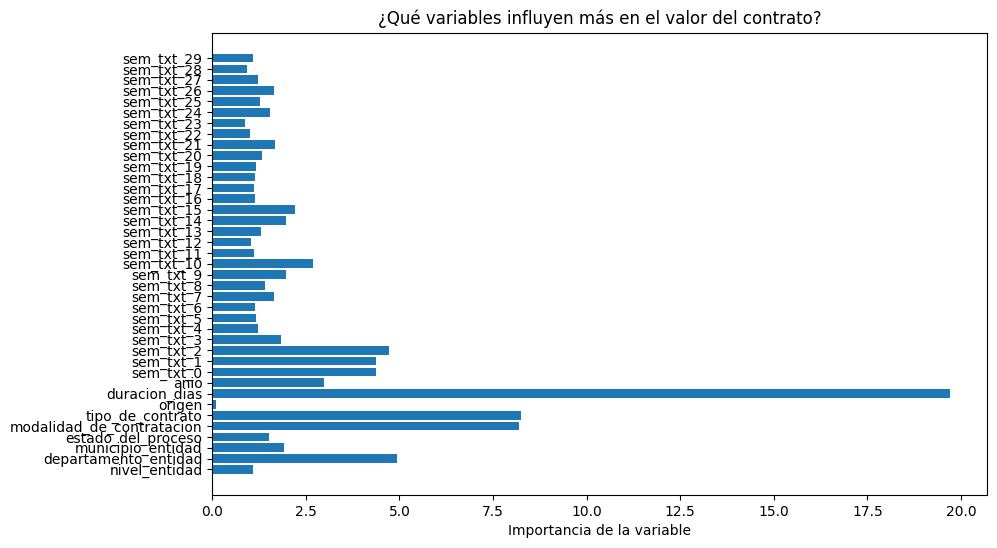

In [ ]:
import matplotlib.pyplot as plt

# Obtener importancia
feature_importance = model.get_feature_importance(train_pool)
feature_names = X_train.columns

# Graficar
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importance)
plt.xlabel('Importancia de la variable')
plt.title('¿Qué variables influyen más en el valor del contrato?')
plt.show()